# Train Schedule coordination – train model

`data/appointment_waittime.csv` → `models/schedule_waittime.joblib`

In [1]:
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
ROOT = Path.cwd() if (Path.cwd()/'data').exists() else Path.cwd().parent
DATA = ROOT/'data'/'appointment_waittime.csv'
MODEL_DIR = ROOT/'models'
MODEL_DIR.mkdir(exist_ok=True)
print(ROOT, DATA.exists())

d:\TTTN-VaxCare-2026\vaxcare-ai True


## 1. Load & khám phá

In [2]:
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(14688, 16)


,date,facility_id,facility_name,day_of_week,is_weekend,is_holiday,hour,time_slot,capacity,capacity_per_slot_base,booked,occupancy_rate,overload_probability,wait_time_minutes,is_busy,alert_threshold
0,2026-05-01,1,VaxCare Phú Nhuận,4,0,1,8,08:00:00,18,15,7,0.389,0.4547,34,0,50
1,2026-05-01,1,VaxCare Phú Nhuận,4,0,1,9,09:00:00,18,15,6,0.333,0.4928,27,0,50
2,2026-05-01,1,VaxCare Phú Nhuận,4,0,1,10,10:00:00,19,15,5,0.263,0.2839,16,0,50
3,2026-05-01,1,VaxCare Phú Nhuận,4,0,1,11,11:00:00,16,15,5,0.312,0.2148,18,0,50
4,2026-05-01,1,VaxCare Phú Nhuận,4,0,1,13,13:00:00,19,15,2,0.105,0.1456,3,0,50


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
facility_id,14688.0,6.500000,3.452170,1.00,3.7500,6.50000,9.2500,12.000
day_of_week,14688.0,3.000000,2.006594,0.00,1.0000,3.00000,5.0000,6.000
is_weekend,14688.0,0.287582,0.452650,0.00,0.0000,0.00000,1.0000,1.000
is_holiday,14688.0,0.019608,0.138653,0.00,0.0000,0.00000,0.0000,1.000
hour,14688.0,12.000000,2.738706,8.00,9.7500,12.00000,14.2500,16.000
capacity,14688.0,13.240128,4.178085,7.00,11.0000,12.00000,16.0000,24.000
capacity_per_slot_base,14688.0,13.000000,2.309480,10.00,11.7500,12.00000,15.0000,18.000
booked,14688.0,6.378745,4.110098,0.00,3.0000,6.00000,9.0000,25.000
occupancy_rate,14688.0,0.478275,0.252419,0.00,0.2860,0.46700,0.6430,1.143
overload_probability,14688.0,0.461090,0.182928,0.01,0.3323,0.45625,0.5847,0.980


## 2. Features

In [4]:
FEATURES = ["day_of_week","is_weekend","is_holiday","hour","capacity","booked","occupancy_rate"]
TARGET = "wait_time_minutes"
X, y = df[FEATURES], df[TARGET]
X.describe()

,day_of_week,is_weekend,is_holiday,hour,capacity,booked,occupancy_rate
count,14688.000000,14688.000000,14688.000000,14688.000000,14688.000000,14688.000000,14688.000000
mean,3.000000,0.287582,0.019608,12.000000,13.240128,6.378745,0.478275
std,2.006594,0.452650,0.138653,2.738706,4.178085,4.110098,0.252419
min,0.000000,0.000000,0.000000,8.000000,7.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,9.750000,11.000000,3.000000,0.286000
50%,3.000000,0.000000,0.000000,12.000000,12.000000,6.000000,0.467000
75%,5.000000,1.000000,0.000000,14.250000,16.000000,9.000000,0.643000
max,6.000000,1.000000,1.000000,16.000000,24.000000,25.000000,1.143000


## 3. Train XGBoost

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.08, subsample=0.85, colsample_bytree=0.85, min_child_weight=3, reg_lambda=1.0, objective='reg:squarederror', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('trained', len(X_train))

trained 11750


## 4. Đánh giá MAE / RMSE / R²

{'mae': 4.8117, 'rmse': 6.0588, 'r2': 0.7946}


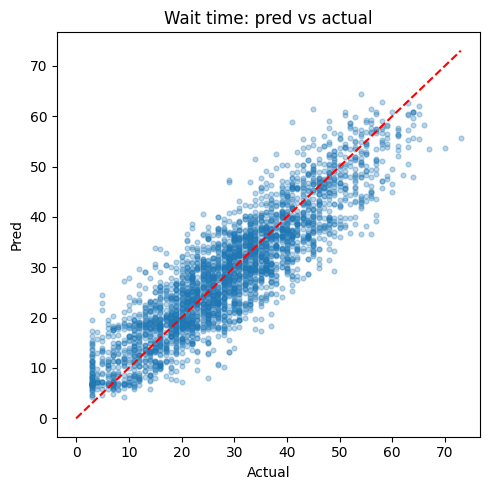

In [6]:
pred = np.clip(model.predict(X_test), 0, None)
metrics = {'mae': round(float(mean_absolute_error(y_test, pred)), 4), 'rmse': round(float(np.sqrt(mean_squared_error(y_test, pred))), 4), 'r2': round(float(r2_score(y_test, pred)), 4)}
print(metrics)
plt.figure(figsize=(5,5)); plt.scatter(y_test, pred, alpha=0.3, s=12)
m = max(y_test.max(), pred.max()); plt.plot([0,m],[0,m],'r--')
plt.xlabel('Actual'); plt.ylabel('Pred'); plt.title('Wait time: pred vs actual'); plt.tight_layout(); plt.show()

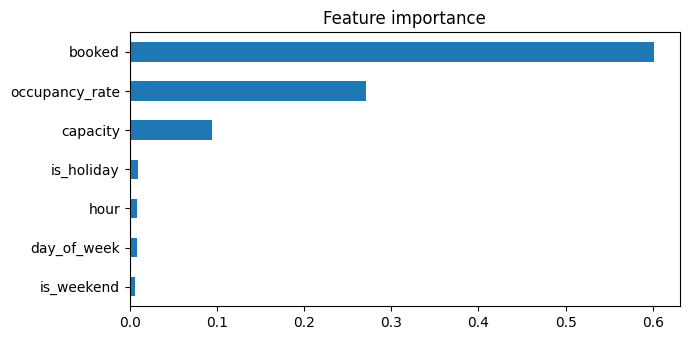

{'day_of_week': 0.0086, 'is_weekend': 0.0066, 'is_holiday': 0.0096, 'hour': 0.0089, 'capacity': 0.0944, 'booked': 0.6011, 'occupancy_rate': 0.2708}


In [7]:
imp = dict(zip(FEATURES, [round(float(x),4) for x in model.feature_importances_]))
pd.Series(imp).sort_values().plot(kind='barh', figsize=(7,3.5), title='Feature importance')
plt.tight_layout(); plt.show(); print(imp)

## 5. Lưu model

In [8]:
artifact = {'model': model, 'features': FEATURES, 'target': TARGET, 'model_version': 'schedule-xgboost-v1', 'metrics': metrics}
out = MODEL_DIR/'schedule_waittime.joblib'
joblib.dump(artifact, out)
(MODEL_DIR/'schedule_metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved', out)

Saved d:\TTTN-VaxCare-2026\vaxcare-ai\models\schedule_waittime.joblib
